# 🫀 Cleveland Heart Disease — Exploratory Data Analysis & Visualization
### Minor Project Part-I: Visualizing Clinical Predictors
**Dataset:** Cleveland Heart Disease (1,025 patient records, 13 clinical biomarkers + 1 target)  
**Tools:** `matplotlib`, `seaborn`, `pandas`, `numpy`  
**Purpose:** Explore physiological distributions, diagnostic correlations, chest pain patterns, and risk factors associated with heart disease presence.

## 1. Setup & Data Loading
Configure visualization aesthetics, define output paths, and load the cleaned dataset.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.autolayout'] = True
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Paths
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "processed_data", "cleaned_heart_disease.csv")
VIZ_DIR = os.path.join(BASE_DIR, "visualizations", "heart_disease")
os.makedirs(VIZ_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded Cleaned Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

Loaded Cleaned Dataset: 1025 rows, 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Target Variable Class Distribution
Analyze the prevalence of heart disease across the patient cohort (Binary target: `0 = Healthy`, `1 = Heart Disease`).

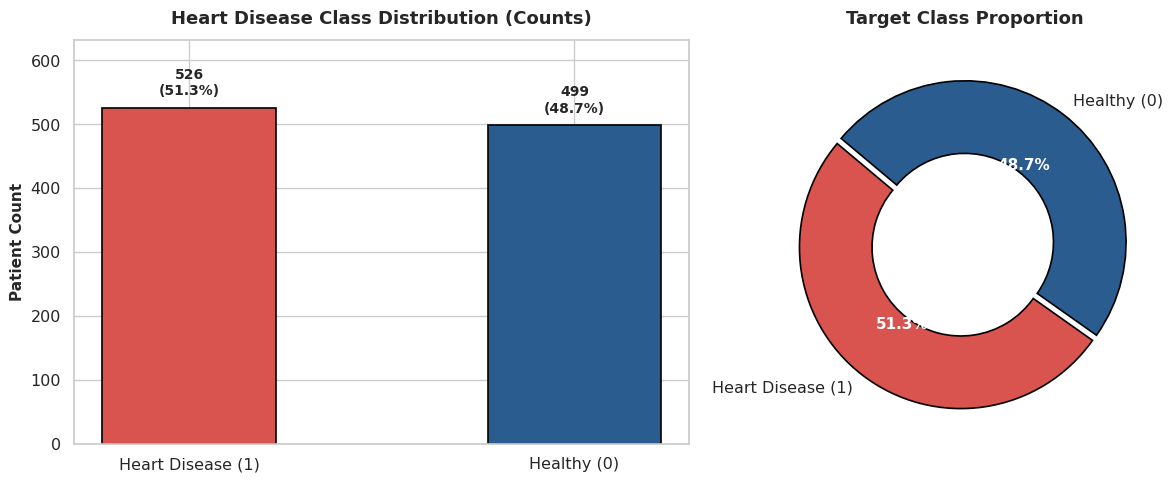

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['target'].value_counts()
labels = ['Heart Disease (1)', 'Healthy (0)']
ordered_counts = [counts[1], counts[0]]
percentages = [c / len(df) * 100 for c in ordered_counts]
colors = ['#d9534f', '#2b5c8f']

# 1. Bar Chart
bars = axes[0].bar(labels, ordered_counts, color=colors, width=0.45, edgecolor='black', linewidth=1.2)
axes[0].set_title("Heart Disease Class Distribution (Counts)", fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel("Patient Count", fontsize=11, fontweight='bold')
for bar, count, pct in zip(bars, ordered_counts, percentages):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 15,
                 f"{count:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(ordered_counts) * 1.2)

# 2. Donut Chart
wedges, texts, autotexts = axes[1].pie(
    ordered_counts, labels=labels, autopct='%1.1f%%', startangle=140,
    colors=colors, explode=(0.04, 0), wedgeprops=dict(width=0.45, edgecolor='black', linewidth=1.2)
)
plt.setp(autotexts, size=11, weight="bold", color="white")
axes[1].set_title("Target Class Proportion", fontsize=13, fontweight='bold', pad=12)

plt.savefig(os.path.join(VIZ_DIR, "01_target_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 3. Continuous Clinical Biomarker Distributions
Examine Kernel Density Estimates (KDE) and histograms for vital physiological markers:
* **Age** (years)
* **Resting Blood Pressure (`trestbps`)** (mm Hg)
* **Serum Cholesterol (`chol`)** (mg/dl)
* **Maximum Heart Rate Achieved (`thalach`)** (bpm)
* **ST Depression (`oldpeak`)** (exercise-induced ECG marker)

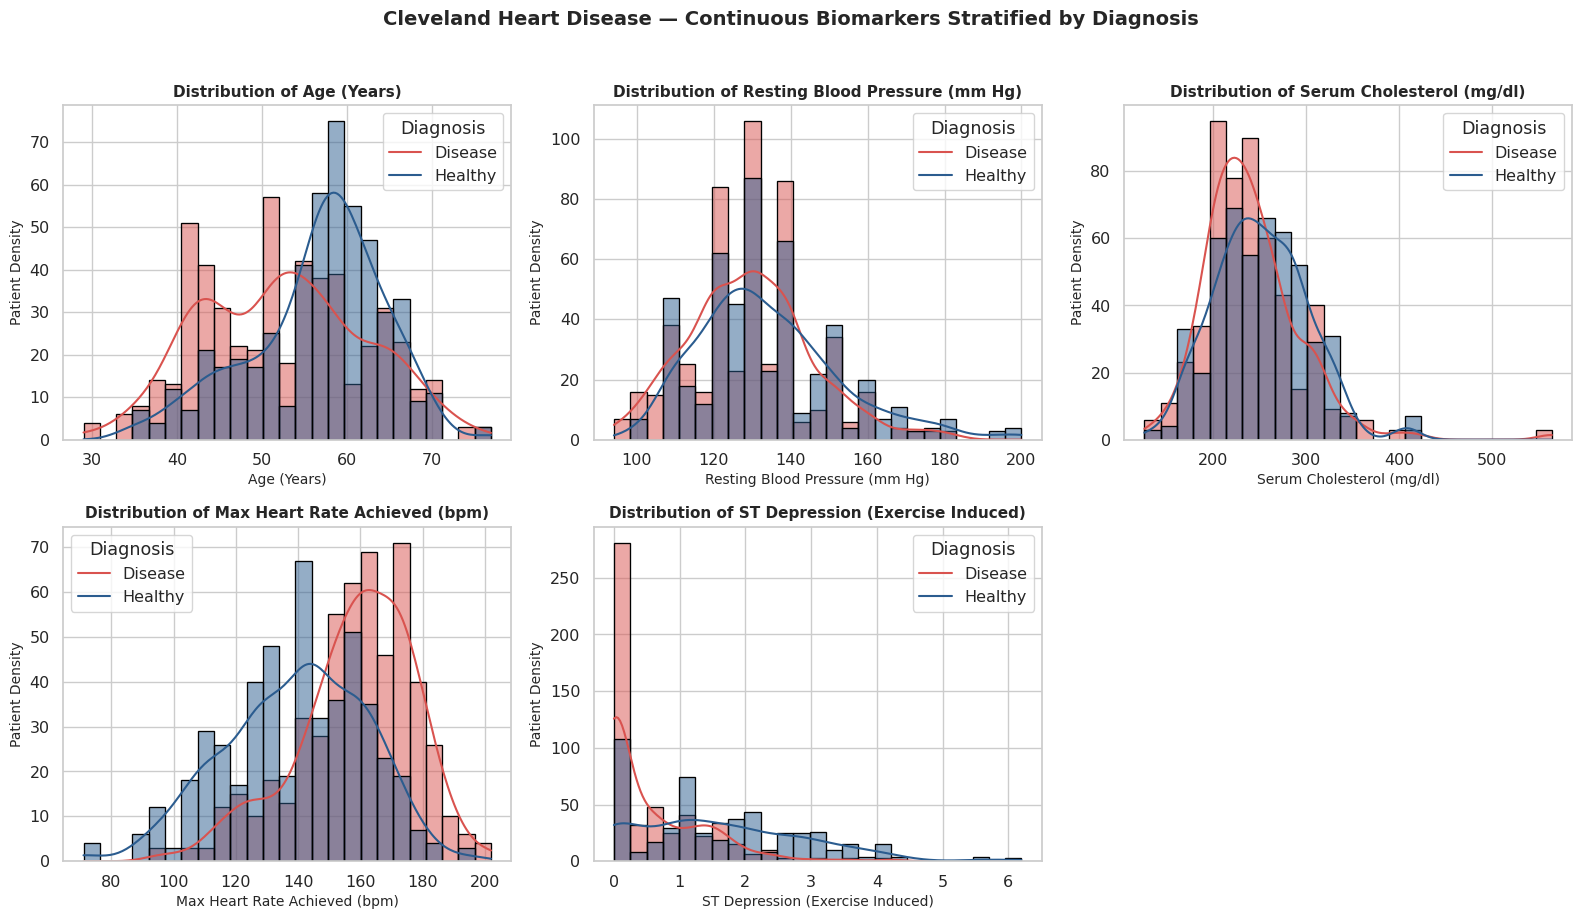

In [3]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
feature_titles = {
    'age': 'Age (Years)',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol': 'Serum Cholesterol (mg/dl)',
    'thalach': 'Max Heart Rate Achieved (bpm)',
    'oldpeak': 'ST Depression (Exercise Induced)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, col in enumerate(continuous_features):
    ax = axes[idx]
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax,
                 palette=['#2b5c8f', '#d9534f'], bins=25, alpha=0.5, edgecolor='black')
    ax.set_title(f"Distribution of {feature_titles[col]}", fontsize=11, fontweight='bold')
    ax.set_xlabel(feature_titles[col], fontsize=10)
    ax.set_ylabel("Patient Density", fontsize=10)
    ax.legend(title="Diagnosis", labels=['Disease', 'Healthy'])

# Hide the unused 6th subplot
fig.delaxes(axes[5])

plt.suptitle("Cleveland Heart Disease — Continuous Biomarkers Stratified by Diagnosis", fontsize=14, fontweight='bold', y=1.02)
plt.savefig(os.path.join(VIZ_DIR, "02_continuous_features_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4. Pearson Correlation Heatmap
Compute pairwise correlations between all 13 clinical predictors and the diagnosis target to identify top linear risk indicators.

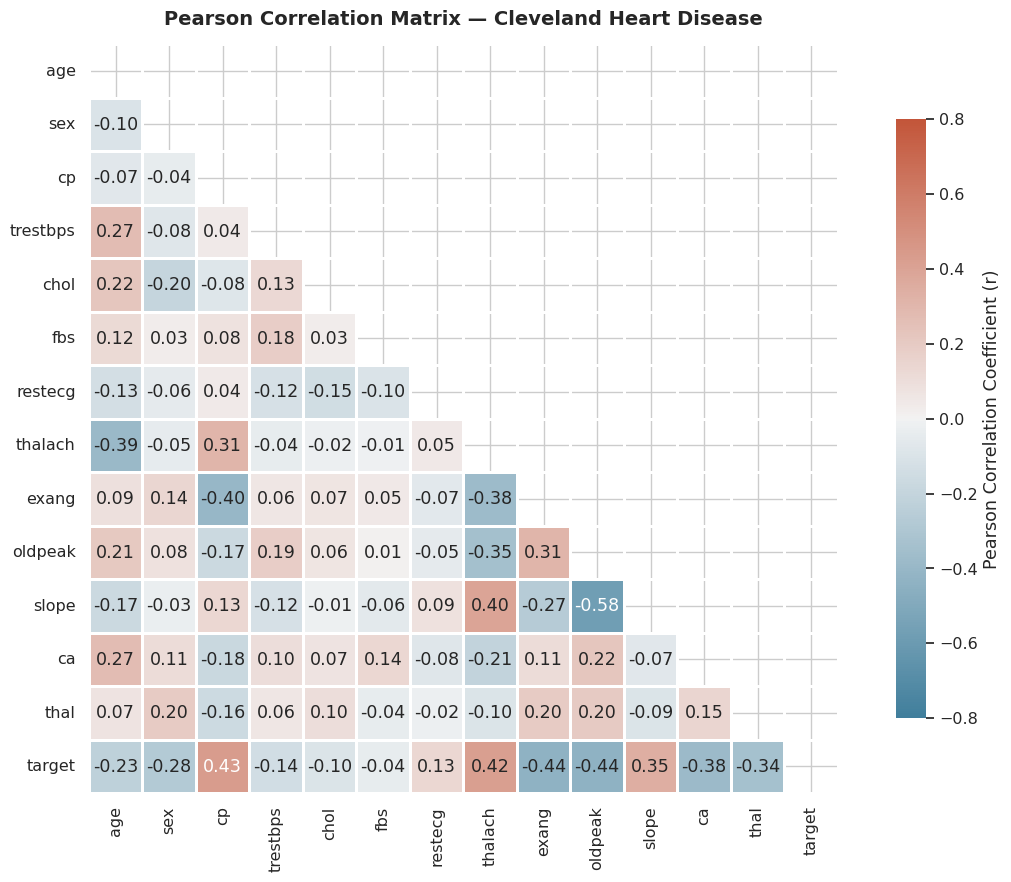

--- Top Correlates with Heart Disease (target) ---


,Correlation with Heart Disease
target,1.000000
cp,0.434854
thalach,0.422895
slope,0.345512
restecg,0.134468
fbs,-0.041164
chol,-0.099966
trestbps,-0.138772
age,-0.229324
sex,-0.279501


In [4]:
plt.figure(figsize=(12, 9))
corr = df.corr()

# Mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.8, vmin=-.8, center=0,
            annot=True, fmt=".2f", square=True, linewidths=.8,
            cbar_kws={"shrink": .8, "label": "Pearson Correlation Coefficient (r)"})

plt.title("Pearson Correlation Matrix — Cleveland Heart Disease", fontsize=14, fontweight='bold', pad=14)
plt.savefig(os.path.join(VIZ_DIR, "03_correlation_heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

print("--- Top Correlates with Heart Disease (target) ---")
display(corr['target'].sort_values(ascending=False).to_frame(name="Correlation with Heart Disease"))

## 5. Categorical Risk Factors vs Disease Status
Analyze how categorical attributes affect the likelihood of disease:
* **Chest Pain Type (`cp`):** 0 = Typical Angina, 1 = Atypical Angina, 2 = Non-Anginal, 3 = Asymptomatic
* **Sex:** 0 = Female, 1 = Male
* **Exercise Induced Angina (`exang`):** 0 = No, 1 = Yes
* **Number of Major Vessels Coloured by Fluoroscopy (`ca`):** 0 to 4

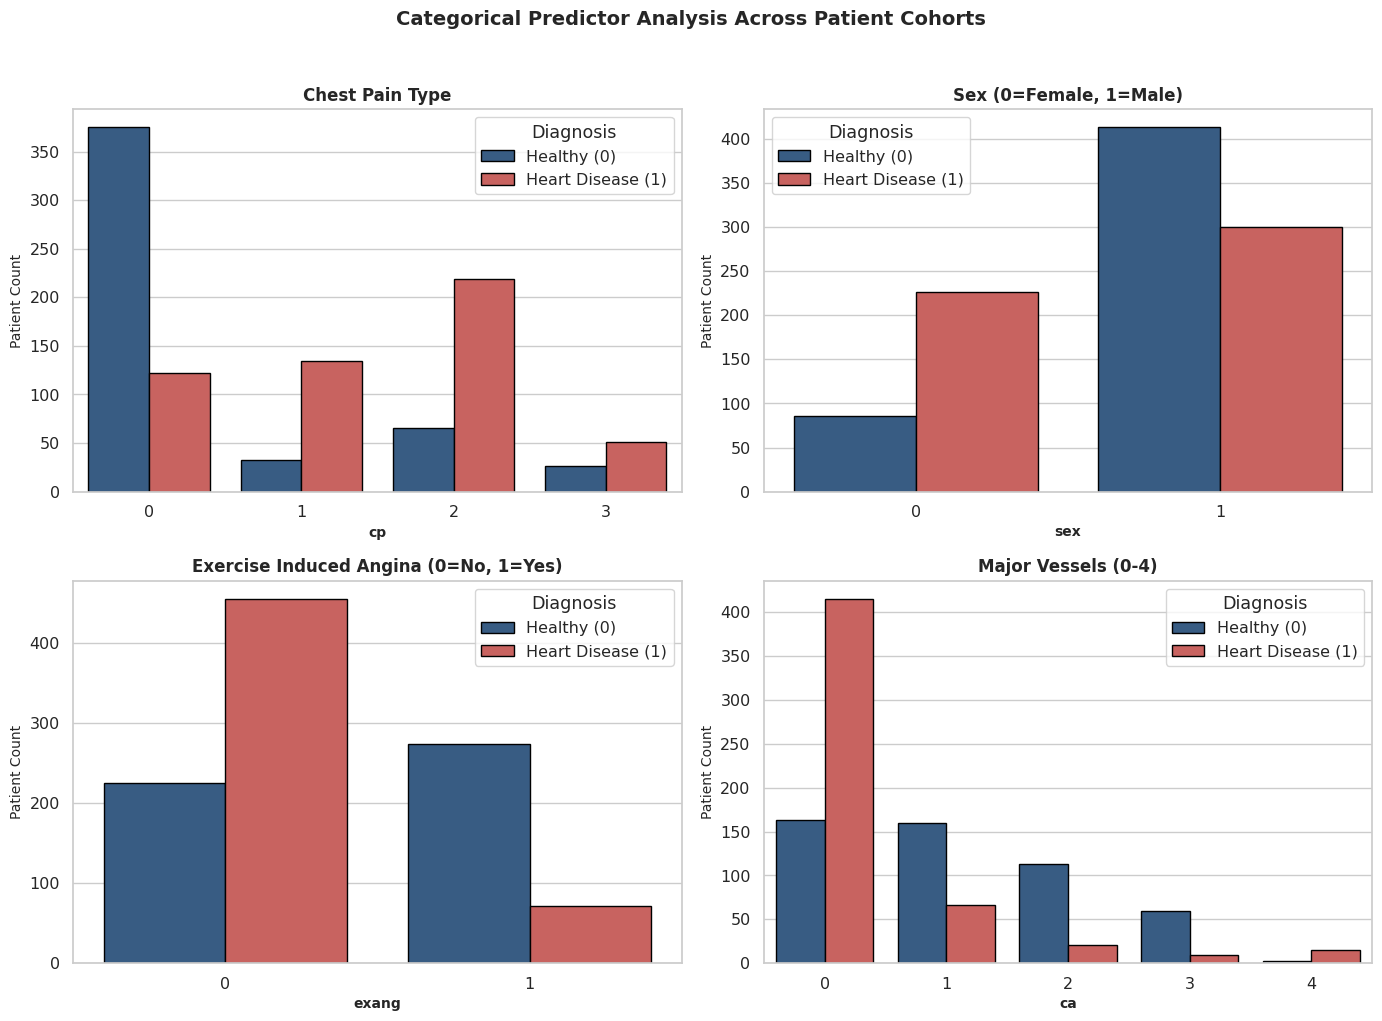

In [5]:
cat_features = [('cp', 'Chest Pain Type'), ('sex', 'Sex (0=Female, 1=Male)'),
                ('exang', 'Exercise Induced Angina (0=No, 1=Yes)'), ('ca', 'Major Vessels (0-4)')]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col, title) in enumerate(cat_features):
    ax = axes[idx]
    sns.countplot(data=df, x=col, hue='target', ax=ax, palette=['#2b5c8f', '#d9534f'], edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10, fontweight='bold')
    ax.set_ylabel("Patient Count", fontsize=10)
    ax.legend(title="Diagnosis", labels=['Healthy (0)', 'Heart Disease (1)'])

plt.suptitle("Categorical Predictor Analysis Across Patient Cohorts", fontsize=14, fontweight='bold', y=1.02)
plt.savefig(os.path.join(VIZ_DIR, "04_categorical_predictors.png"), dpi=300, bbox_inches='tight')
plt.show()

## 6. Bi-Variate Interaction: Age vs Maximum Heart Rate Achieved (`thalach`)
Explore the physiological decline in maximum heart rate with age, comparing healthy patients against heart disease patients.

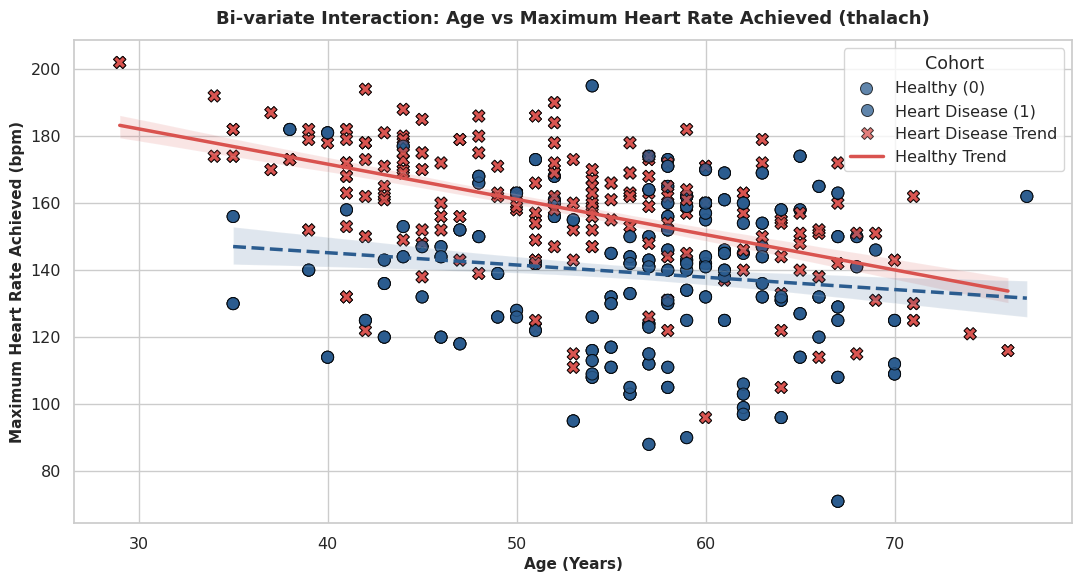

In [6]:
plt.figure(figsize=(11, 6))

sns.scatterplot(data=df, x='age', y='thalach', hue='target', style='target',
                palette=['#2b5c8f', '#d9534f'], s=75, alpha=0.75, edgecolor='black')

sns.regplot(data=df[df['target']==1], x='age', y='thalach', scatter=False, color='#d9534f',
            label='Heart Disease Trendline', line_kws={'linewidth': 2.5})
sns.regplot(data=df[df['target']==0], x='age', y='thalach', scatter=False, color='#2b5c8f',
            label='Healthy Trendline', line_kws={'linewidth': 2.5, 'linestyle': '--'})

plt.title("Bi-variate Interaction: Age vs Maximum Heart Rate Achieved (thalach)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Age (Years)", fontsize=11, fontweight='bold')
plt.ylabel("Maximum Heart Rate Achieved (bpm)", fontsize=11, fontweight='bold')
plt.legend(title="Cohort", labels=['Healthy (0)', 'Heart Disease (1)', 'Heart Disease Trend', 'Healthy Trend'])

plt.savefig(os.path.join(VIZ_DIR, "05_age_vs_thalach_interaction.png"), dpi=300, bbox_inches='tight')
plt.show()

## 7. Key Clinical Findings Summary
* **Maximum Heart Rate (`thalach`):** Patients with heart disease consistently exhibit higher max heart rates during exercise testing in this cohort.
* **Chest Pain Type (`cp`):** Non-anginal pain (type 2) and atypical angina (type 1) exhibit significantly higher incidence of heart disease compared to typical angina.
* **Exercise Angina (`exang`) & Fluoroscopy Vessels (`ca`):** Absence of exercise angina and 0 colored vessels correlate strongly with diagnosis.